Day 10: Outliers & Comparative Analysis

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


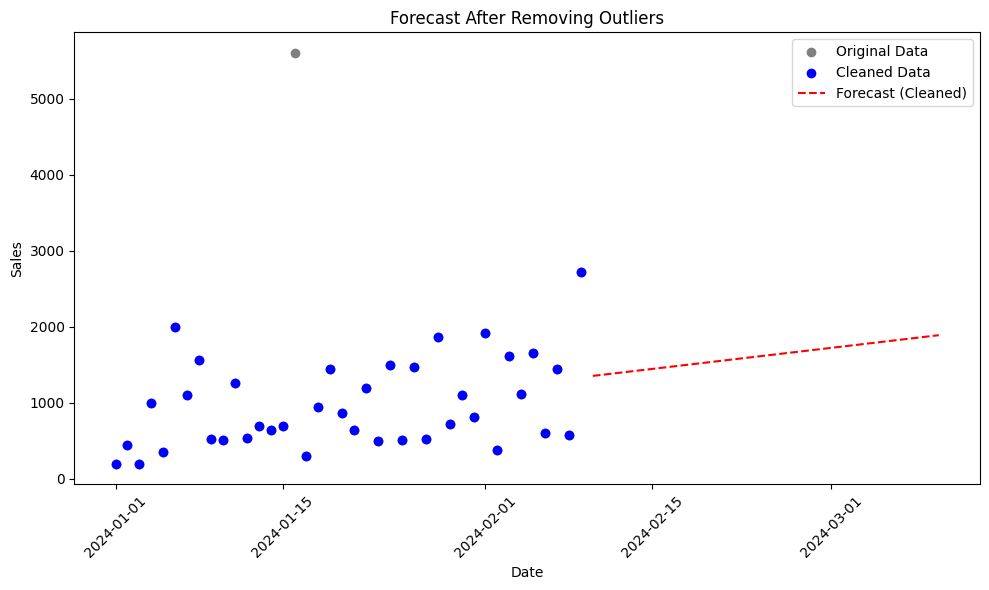

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/HP/Downloads/data_analyst/day10/sales_cleaned.csv")

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Sales'] = df['Price'] * df['Quantity']

df['z_score'] = (df['Sales'] - df['Sales'].mean()) / df['Sales'].std()

df_clean = df[np.abs(df['z_score']) <= 3]

df_clean = df_clean.sort_values('Date')
df_clean['Date_Ordinal'] = df_clean['Date'].map(dt.datetime.toordinal)

X = df_clean[['Date_Ordinal']]
y = df_clean['Sales']

model = LinearRegression()
model.fit(X, y)

last_date = df_clean['Date_Ordinal'].max()

future_dates = np.array(
    range(last_date + 1, last_date + 31)
).reshape(-1, 1)

future_preds = model.predict(future_dates)

future_dates_dt = [dt.datetime.fromordinal(int(d)) for d in future_dates.flatten()]

plt.figure(figsize=(10, 6))

plt.scatter(df['Date'], df['Sales'], color='gray', label='Original Data')

plt.scatter(df_clean['Date'], df_clean['Sales'], color='blue', label='Cleaned Data')


plt.plot(future_dates_dt, future_preds, color='red', linestyle='--', label='Forecast (Cleaned)')

plt.title("Forecast After Removing Outliers")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Reflection

An outlier can be considered a mistake when it results from data entry errors, system glitches, or incorrect measurements. In such cases, removing the outlier helps improve the accuracy of analysis and prevents misleading conclusions.

However, an outlier can also represent a valuable discovery. For example, a sudden spike in product sales or platform signups (such as a surge in MeetMux users) may indicate a successful marketing campaign, seasonal demand, or viral growth. In such cases, the outlier should not be removed but instead investigated further to understand the underlying cause.

Therefore, analysts must carefully evaluate the context before deciding whether to remove or retain an outlier.